# 🎯 Face Mask Detection — Model Evaluation

### 📌 Objective
Evaluate the trained face mask detection model using:
- Test Accuracy
- Confusion Matrix
- Classification Metrics
- Misclassified Images
- Error Analysis

---

### 📁 Inputs:
- Trained Model: `mask_detector.pth`
- Test Dataset

### 📁 Outputs:
- confusion_matrix.png
- classification_report.txt
- misclassified_images.png
- evaluation_summary.txt

# **Imports & Setup**

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# **Device Configuration**

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# **Load Test Dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Path to test dataset (UPDATE if needed)
test_dir = "/content/drive/MyDrive/Test"

# Transform (same as training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

test_dataset = datasets.ImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = test_dataset.classes
print("Classes:", class_names)

Classes: ['WithMask', 'WithoutMask']


# **Load Model**

In [9]:
model_path = "/content/mask_detector.pth"

# Load checkpoint
checkpoint = torch.load(model_path, map_location="cpu")

# Load base model
model = models.mobilenet_v2(weights=None)

# Recreate classifier EXACTLY as teammate did
in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(256, 2)
)

# Load weights correctly
model.load_state_dict(checkpoint["model_state_dict"])

model = model.to(device)
model.eval()

print("✅ Model loaded successfully")

# Optional (recommended)
class_names = checkpoint.get("class_names", ["with_mask", "without_mask"])
print("Classes:", class_names)

✅ Model loaded successfully
Classes: ['WithMask', 'WithoutMask']


# **Evaluate Model (Accuracy)**

In [10]:
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Save accuracy
with open("test_accuracy.txt", "w") as f:
    f.write(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 83.87%


# **Confusion Matrix**

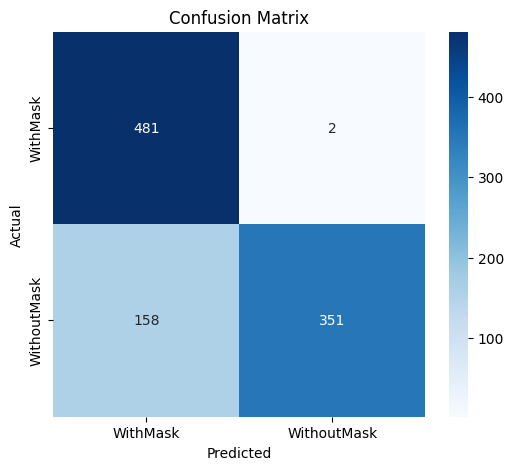

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

# **Classification Report**

In [12]:
report = classification_report(y_true, y_pred, target_names=class_names)

print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)

              precision    recall  f1-score   support

    WithMask       0.75      1.00      0.86       483
 WithoutMask       0.99      0.69      0.81       509

    accuracy                           0.84       992
   macro avg       0.87      0.84      0.84       992
weighted avg       0.88      0.84      0.84       992



# **Misclassified Images**

In [13]:
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):
            if preds[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_labels.append(labels[i].item())
                misclassified_preds.append(preds[i].item())

print("Total Misclassified Images:", len(misclassified_images))

Total Misclassified Images: 160


**Display Misclassified Images**

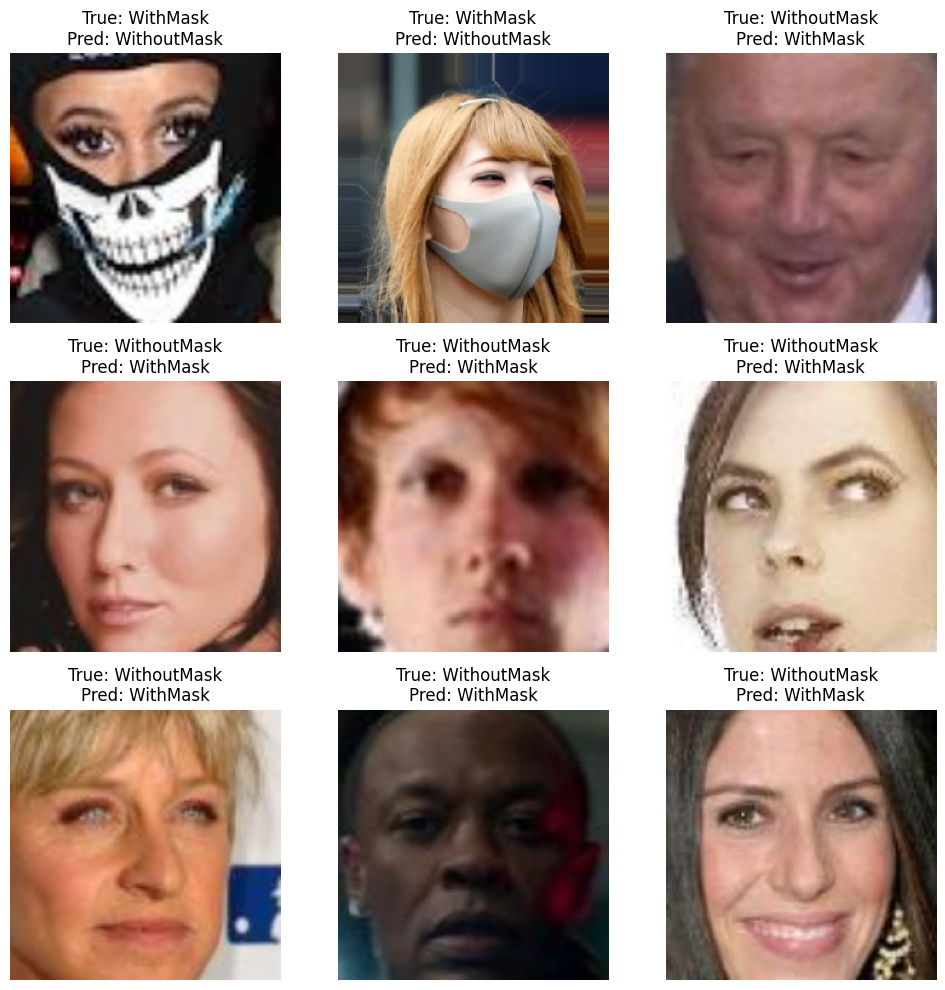

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(10,10))

for i, ax in enumerate(axes.flatten()):
    if i >= len(misclassified_images):
        break

    img = misclassified_images[i].permute(1, 2, 0)
    ax.imshow(img)
    ax.set_title(f"True: {class_names[misclassified_labels[i]]}\nPred: {class_names[misclassified_preds[i]]}")
    ax.axis("off")

plt.tight_layout()
plt.savefig("misclassified_images.png")
plt.show()

## ❗ Error Analysis

Most misclassified images occurred when:

- Masks were worn incorrectly
- Images had low lighting conditions
- Faces were partially visible
- Side-angle faces were present

The model performed best on:
- Clear frontal face images
- Good lighting conditions
- Proper mask usage

### 📌 Insight:
The model struggles with real-world variations such as occlusions and lighting, which suggests that adding more diverse training data could improve performance.

# **Evaluation Summary File**

In [15]:
summary = f"""
Model Evaluation Summary

Test Accuracy: {accuracy * 100:.2f}%

{report}

Total Misclassified Images: {len(misclassified_images)}

Error Analysis:
- Errors occur in low lighting
- Side faces
- Incorrect mask usage

Conclusion:
The model performs well but can be improved with more diverse data.
"""

with open("evaluation_summary.txt", "w") as f:
    f.write(summary)

print("✅ Evaluation summary saved")

✅ Evaluation summary saved
